# CMIP6 Case A — Step 3: Grid-level P–ET–R relationships and interannual stability

**English.** This notebook uses the annual non-ice land dataset produced in Step 2 to quantify how precipitation (P), evapotranspiration (ET), and runoff (R) co-vary from year to year at every model grid cell during 1985–2014. It evaluates relationship strength, early-versus-late consistency, interannual variability, partition-ratio dispersion, and water-balance residual stability. This is descriptive EDA: it does not fit a tree model, assign Köppen classes, or claim causality.

**中文。** 本 notebook 使用 Step 2 生成的非冰川陆地年度数据，分析 1985–2014 年间每一个模式网格中降水（P）、蒸散发（ET）和径流（R）的年际共同变化。分析内容包括关系强度、前后半期一致性、年际变异、水分分配比例的离散程度，以及水量平衡残差的稳定性。本步骤属于描述性 EDA：暂不建立 tree 模型、不加入 Köppen 分类，也不进行因果解释。


## Step 0 — Configuration and visual style

**English.** Load the analysis libraries, locate `case/caseA` robustly, define the 1985–2014 period, and use framed axes and consistent map styling. All spatial summaries are weighted by non-ice land area, not by raw grid-cell count.

**中文。** 加载分析工具，自动定位 `case/caseA`，设定 1985–2014 分析时段，并统一带边框的绘图风格。所有空间汇总均使用非冰川陆地面积加权，而不是简单按网格数量平均。


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import cartopy.crs as ccrs
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="ticks", context="notebook")
plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 220,
    "figure.facecolor": "white", "axes.facecolor": "white",
    "font.family": "DejaVu Sans", "axes.edgecolor": "#30343B",
    "axes.linewidth": 0.9, "axes.titlesize": 11,
    "axes.titleweight": "semibold", "axes.labelsize": 10,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

START_YEAR, END_YEAR = 1985, 2014
EARLY_END, LATE_START = 1999, 2000
STABLE_DELTA_R = 0.30
STRONG_ABS_R = 0.50
WRITE_OUTPUTS = True

def find_case_dir(start=Path.cwd()):
    start = start.resolve()
    for base in (start, *start.parents):
        if base.name.lower() == "casea":
            return base
        candidate = base / "case" / "caseA"
        if candidate.exists():
            return candidate
    raise FileNotFoundError("Could not locate case/caseA.")

def style_axes(ax):
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("#30343B")
        spine.set_linewidth(0.9)
    ax.tick_params(direction="out", length=3.5, width=0.75, color="#30343B")
    ax.grid(True, color="#E1E5EA", linewidth=0.55, alpha=0.85, zorder=0)

CASE_DIR = find_case_dir()
DERIVED_DIR = CASE_DIR / "derived"
FIGURE_DIR = DERIVED_DIR / "figures_step3"
ANNUAL_TABLE = DERIVED_DIR / "MPI_ESM1_2_LR_water_cycle_grid_year_1985_2014.parquet"
ANNUAL_NETCDF = DERIVED_DIR / "MPI_ESM1_2_LR_water_cycle_annual_1985_2014.nc"

print(f"Case directory: {CASE_DIR}")
print(f"Analysis period: {START_YEAR}–{END_YEAR}")


Case directory: /Users/mimi/Documents/Code/Github/GSA-work/explore/sythetic/case/caseA
Analysis period: 1985–2014


## Step 1 — Load and audit the annual panel

**English.** Read the grid-year Parquet table and the spatial NetCDF product from Step 2. Verify that every analysis grid contains exactly 30 annual observations and that P, ET, R, and WB contain no missing values. Ratio variables may be missing when annual P ≤ 1 mm yr⁻¹; this avoids unstable division by a near-zero denominator without removing the grid cell from the primary analysis.

**中文。** 读取 Step 2 生成的逐网格逐年 Parquet 表和空间 NetCDF。检查每个分析网格是否都具有完整的 30 年记录，并确认 P、ET、R、WB 没有缺失。若某年 P ≤ 1 mm yr⁻¹，则比例变量允许为空，这是为了避免接近零的分母造成异常比例；该网格仍保留在主要变量分析中，并没有使用 P > 50 的筛选。


In [2]:
if not ANNUAL_TABLE.exists() or not ANNUAL_NETCDF.exists():
    raise FileNotFoundError("Run CMIP_step2_prepare_annual_dataset.ipynb first.")

annual = pd.read_parquet(ANNUAL_TABLE).sort_values(["grid_id", "year"]).reset_index(drop=True)
spatial = xr.open_dataset(ANNUAL_NETCDF)

expected_years = END_YEAR - START_YEAR + 1
years_per_grid = annual.groupby("grid_id")["year"].nunique()
audit = pd.Series({
    "rows": len(annual),
    "non_ice_grid_cells": annual["grid_id"].nunique(),
    "minimum_year": int(annual["year"].min()),
    "maximum_year": int(annual["year"].max()),
    "minimum_years_per_grid": int(years_per_grid.min()),
    "maximum_years_per_grid": int(years_per_grid.max()),
    "duplicate_grid_year_keys": int(annual.duplicated(["grid_id", "year"]).sum()),
    "missing_primary_rows": int(annual[["P", "ET", "R", "WB"]].isna().any(axis=1).sum()),
})
display(audit.to_frame("value"))

assert years_per_grid.min() == expected_years and years_per_grid.max() == expected_years
assert audit["duplicate_grid_year_keys"] == 0
assert audit["missing_primary_rows"] == 0


,value
rows,125160
non_ice_grid_cells,4172
minimum_year,1985
maximum_year,2014
minimum_years_per_grid,30
maximum_years_per_grid,30
duplicate_grid_year_keys,0
missing_primary_rows,0


## Step 2 — Define relationship and stability metrics

**English.** For each grid cell, calculate Pearson correlations for P–ET, P–R, and ET–R, plus Spearman correlations as a monotonicity check. Pearson slopes describe the absolute response of ET or R to a 1 mm change in P. Correlations are computed after removing each grid cell's own 30-year mean, so spatial mean differences do not create the relationship.

Interannual stability is evaluated using complementary quantities:

- mean, standard deviation, and coefficient of variation (CV) for P, ET, and R;
- long-term ET/P and R/P from the ratio of 30-year means;
- median and interquartile range (IQR) of valid annual ET/P and R/P values;
- mean, standard deviation, mean absolute error, and RMSE of WB = P − ET − R.

**中文。** 对每个网格计算 P–ET、P–R 和 ET–R 的 Pearson 相关系数，并使用 Spearman 相关作为单调关系的补充检查。Pearson 斜率表示 P 每变化 1 mm 时 ET 或 R 的平均响应。计算相关性之前，会在每个网格内部去除各自的 30 年均值，因此不同地区的空间均值差异不会被误认为年际关系。

年际稳定性使用以下互补指标衡量：

- P、ET、R 的均值、标准差和变异系数（CV）；
- 使用 30 年均值之比得到的长期 ET/P 与 R/P；
- 有效年度 ET/P 与 R/P 的中位数和四分位距（IQR）；
- WB = P − ET − R 的均值、标准差、平均绝对值和 RMSE。


In [3]:
def grouped_pearson(frame, x, y):
    grouped = frame.groupby("grid_id", sort=False)
    x_centered = frame[x] - grouped[x].transform("mean")
    y_centered = frame[y] - grouped[y].transform("mean")
    numerator = (x_centered * y_centered).groupby(frame["grid_id"], sort=False).sum()
    denominator = np.sqrt(
        (x_centered * x_centered).groupby(frame["grid_id"], sort=False).sum()
        * (y_centered * y_centered).groupby(frame["grid_id"], sort=False).sum()
    )
    return (numerator / denominator).replace([np.inf, -np.inf], np.nan)

def grouped_spearman(frame, x, y):
    ranked = frame[["grid_id", x, y]].copy()
    ranked[x] = ranked.groupby("grid_id")[x].rank(method="average")
    ranked[y] = ranked.groupby("grid_id")[y].rank(method="average")
    return grouped_pearson(ranked, x, y)

def weighted_quantile(values, weights, quantile=0.5):
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    valid = np.isfinite(values) & np.isfinite(weights) & (weights > 0)
    order = np.argsort(values[valid])
    sorted_values = values[valid][order]
    cumulative = np.cumsum(weights[valid][order])
    return float(sorted_values[np.searchsorted(cumulative, quantile * cumulative[-1])])

static_columns = [
    "grid_id", "grid_id_numeric", "lat", "lon", "cell_area", "land_area",
    "land_fraction", "land_ice_fraction",
]
metrics = annual[static_columns].drop_duplicates("grid_id").set_index("grid_id").sort_index()
grouped = annual.groupby("grid_id")

for variable in ["P", "ET", "R", "WB"]:
    metrics[f"{variable}_mean"] = grouped[variable].mean()
    metrics[f"{variable}_sd"] = grouped[variable].std(ddof=1)
    metrics[f"{variable}_cv"] = metrics[f"{variable}_sd"] / metrics[f"{variable}_mean"].abs()

relationship_pairs = {
    "P_ET": ("P", "ET"),
    "P_R": ("P", "R"),
    "ET_R": ("ET", "R"),
}
for label, (x, y) in relationship_pairs.items():
    metrics[f"r_{label}"] = grouped_pearson(annual, x, y)
    metrics[f"rho_{label}"] = grouped_spearman(annual, x, y)

metrics["P_to_ET_slope"] = metrics["r_P_ET"] * metrics["ET_sd"] / metrics["P_sd"]
metrics["P_to_R_slope"] = metrics["r_P_R"] * metrics["R_sd"] / metrics["P_sd"]
metrics["ET_fraction_longterm"] = metrics["ET_mean"] / metrics["P_mean"]
metrics["R_fraction_longterm"] = metrics["R_mean"] / metrics["P_mean"]
metrics["partition_sum_longterm"] = metrics["ET_fraction_longterm"] + metrics["R_fraction_longterm"]

for ratio in ["ET_over_P", "R_over_P"]:
    metrics[f"{ratio}_median"] = grouped[ratio].median()
    metrics[f"{ratio}_iqr"] = grouped[ratio].quantile(0.75) - grouped[ratio].quantile(0.25)
    metrics[f"{ratio}_valid_years"] = grouped[ratio].count()

metrics["WB_mae"] = grouped["WB"].apply(lambda values: values.abs().mean())
metrics["WB_rmse"] = grouped["WB"].apply(lambda values: np.sqrt(np.mean(values * values)))
metrics["WB_relative_percent"] = 100 * metrics["WB_mean"] / metrics["P_mean"]
metrics["WB_positive_fraction"] = grouped["WB"].apply(lambda values: (values > 0).mean())

display(metrics.head(3).round(3))


,grid_id_numeric,lat,lon,cell_area,land_area,land_fraction,land_ice_fraction,P_mean,P_sd,P_cv,...,ET_over_P_median,ET_over_P_iqr,ET_over_P_valid_years,R_over_P_median,R_over_P_iqr,R_over_P_valid_years,WB_mae,WB_rmse,WB_relative_percent,WB_positive_fraction
grid_id,,,,,,,,,,,,,,,,,,,,,
MPI_LR_000001,1,-55.025,-69.375,2.478351e+10,2.478351e+10,100.0,0.0,1283.296997,64.820999,0.051,...,0.470,0.022,30,0.531,0.027,30,3.074,5.006,0.011,0.433
MPI_LR_000002,2,-55.025,-67.500,2.478351e+10,2.478351e+10,100.0,0.0,1050.723022,55.734001,0.053,...,0.560,0.030,30,0.442,0.025,30,6.447,9.518,0.008,0.533
MPI_LR_000003,3,-53.160,-73.125,2.592378e+10,2.592378e+10,100.0,0.0,1668.251953,115.213997,0.069,...,0.439,0.028,30,0.559,0.027,30,3.632,5.732,0.002,0.500


## Step 3 — Test early-versus-late relationship consistency

**English.** Recalculate P–ET and P–R correlations separately for 1985–1999 and 2000–2014. The absolute difference, |r_late − r_early|, measures temporal sensitivity, while sign consistency records whether the relationship keeps the same direction. A diagnostic “strong and stable” flag requires |r_full| ≥ 0.50, the same sign in both halves, and Δr ≤ 0.30. These thresholds are transparent EDA rules, not a new climate classification.

**中文。** 分别在 1985–1999 和 2000–2014 两个 15 年时段重新计算 P–ET 与 P–R 相关。绝对差值 |r_late − r_early| 衡量关系随时间的变化程度；符号一致性表示前后两段关系方向是否相同。诊断性的“强且稳定”标记要求：完整时段 |r| ≥ 0.50、前后两段符号一致、并且 Δr ≤ 0.30。这里的阈值只是透明的 EDA 规则，不是新的气候分类。


In [4]:
early = annual.loc[annual["year"] <= EARLY_END]
late = annual.loc[annual["year"] >= LATE_START]

for label, (x, y) in {"P_ET": ("P", "ET"), "P_R": ("P", "R")}.items():
    metrics[f"r_{label}_early"] = grouped_pearson(early, x, y)
    metrics[f"r_{label}_late"] = grouped_pearson(late, x, y)
    metrics[f"r_{label}_delta_abs"] = (
        metrics[f"r_{label}_late"] - metrics[f"r_{label}_early"]
    ).abs()
    metrics[f"r_{label}_sign_consistent"] = (
        np.sign(metrics[f"r_{label}_early"]) == np.sign(metrics[f"r_{label}_late"])
    )
    metrics[f"{label}_strong_stable"] = (
        (metrics[f"r_{label}"].abs() >= STRONG_ABS_R)
        & metrics[f"r_{label}_sign_consistent"]
        & (metrics[f"r_{label}_delta_abs"] <= STABLE_DELTA_R)
    )

display(metrics[[
    "r_P_ET", "r_P_ET_early", "r_P_ET_late", "r_P_ET_delta_abs",
    "r_P_ET_sign_consistent", "P_ET_strong_stable",
    "r_P_R", "r_P_R_early", "r_P_R_late", "r_P_R_delta_abs",
    "r_P_R_sign_consistent", "P_R_strong_stable",
]].head().round(3))


,r_P_ET,r_P_ET_early,r_P_ET_late,r_P_ET_delta_abs,r_P_ET_sign_consistent,P_ET_strong_stable,r_P_R,r_P_R_early,r_P_R_late,r_P_R_delta_abs,r_P_R_sign_consistent,P_R_strong_stable
grid_id,,,,,,,,,,,,
MPI_LR_000001,0.399,0.450,0.340,0.110,True,False,0.941,0.941,0.951,0.010,True,True
MPI_LR_000002,0.544,0.514,0.577,0.064,True,True,0.916,0.914,0.918,0.004,True,True
MPI_LR_000003,0.677,0.841,0.550,0.291,True,True,0.971,0.977,0.986,0.009,True,True
MPI_LR_000004,0.462,0.601,0.536,0.065,True,False,0.884,0.831,0.945,0.114,True,True
MPI_LR_000005,0.652,0.495,0.780,0.285,True,True,0.801,0.540,0.879,0.339,True,False


## Step 4 — Quality control and area-weighted summary

**English.** Confirm that the metric table has one row per analysis grid, all correlations remain within [−1, 1], and the stored WB identity is exact. Summaries report area-weighted medians and land-area shares, preventing small high-latitude grid cells from receiving the same influence as large cells.

**中文。** 检查结果表是否每个分析网格只有一行、所有相关系数是否位于 [−1, 1]、以及 WB = P − ET − R 是否保持精确一致。汇总采用陆地面积加权中位数和面积占比，从而避免较小的高纬度网格与较大的低纬度网格具有相同权重。


In [5]:
relationship_columns = ["r_P_ET", "r_P_R", "r_ET_R"]
weights = metrics["land_area"].astype(float)

def weighted_share(mask):
    mask = pd.Series(mask, index=metrics.index).fillna(False)
    return float(weights[mask].sum() / weights.sum())

summary_rows = []
for label, display_name in [
    ("P_ET", "P–ET"), ("P_R", "P–R"), ("ET_R", "ET–R")
]:
    row = {
        "relationship": display_name,
        "area_weighted_median_r": weighted_quantile(metrics[f"r_{label}"], weights),
        "land_area_share_abs_r_ge_0.5": weighted_share(metrics[f"r_{label}"].abs() >= STRONG_ABS_R),
    }
    if label in ["P_ET", "P_R"]:
        row.update({
            "area_weighted_median_delta_r": weighted_quantile(metrics[f"r_{label}_delta_abs"], weights),
            "land_area_share_same_sign": weighted_share(metrics[f"r_{label}_sign_consistent"]),
            "land_area_share_strong_stable": weighted_share(metrics[f"{label}_strong_stable"]),
        })
    summary_rows.append(row)

relationship_summary = pd.DataFrame(summary_rows).set_index("relationship")
variability_summary = pd.DataFrame({
    "area_weighted_median": {
        "P CV": weighted_quantile(metrics["P_cv"], weights),
        "ET CV": weighted_quantile(metrics["ET_cv"], weights),
        "R CV": weighted_quantile(metrics["R_cv"], weights),
        "ET/P annual IQR": weighted_quantile(metrics["ET_over_P_iqr"], weights),
        "R/P annual IQR": weighted_quantile(metrics["R_over_P_iqr"], weights),
        "|mean WB| / mean P (%)": weighted_quantile(metrics["WB_relative_percent"].abs(), weights),
    }
})

display(relationship_summary.round(3))
display(variability_summary.round(3))

wb_identity_error = float((annual["P"] - annual["ET"] - annual["R"] - annual["WB"]).abs().max())
assert len(metrics) == annual["grid_id"].nunique()
assert metrics.index.is_unique
assert metrics[relationship_columns].notna().all().all()
assert (metrics[relationship_columns].abs() <= 1 + 1e-6).all().all()
assert wb_identity_error < 1e-6


,area_weighted_median_r,land_area_share_abs_r_ge_0.5,area_weighted_median_delta_r,land_area_share_same_sign,land_area_share_strong_stable
relationship,,,,,
P–ET,0.771,0.672,0.080,0.888,0.637
P–R,0.865,0.925,0.055,0.993,0.877
ET–R,0.550,0.548,NaN,NaN,NaN


,area_weighted_median
P CV,0.168
ET CV,0.114
R CV,0.335
ET/P annual IQR,0.103
R/P annual IQR,0.033
|mean WB| / mean P (%),0.177


## Step 5 — Map relationship strength

**English.** Map the three full-period Pearson correlations on the model grid. A shared diverging scale makes the signs and magnitudes directly comparable. Correlations near +1 indicate that the two variables rise and fall together across years; values near 0 indicate a weak linear interannual relationship; negative values indicate opposing year-to-year changes.

**中文。** 在模式原始网格上绘制三个完整时段 Pearson 相关系数，并统一使用发散色标，便于直接比较方向和强度。接近 +1 表示两个变量在不同年份中同步升降；接近 0 表示线性年际关系较弱；负值则表示两者年际变化方向相反。


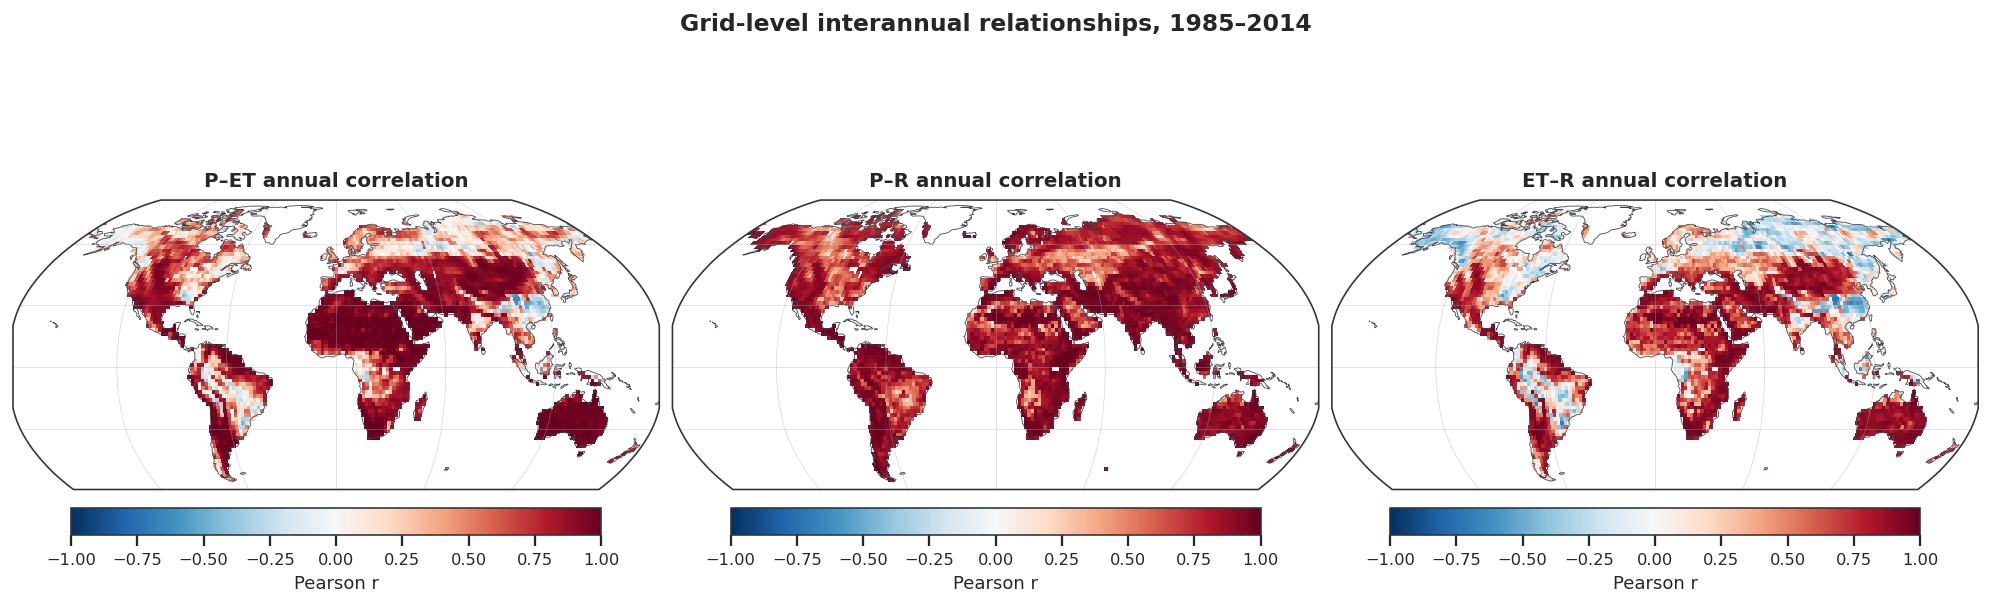

In [6]:
def metric_grid(column):
    numeric_ids = metrics["grid_id_numeric"].astype(int).to_numpy()
    lookup = np.full(int(numeric_ids.max()) + 1, np.nan, dtype="float32")
    lookup[numeric_ids] = metrics[column].astype(float).to_numpy()
    source_ids = spatial["grid_id"].fillna(-1).values.astype(int)
    safe_ids = np.where(source_ids > 0, source_ids, 0)
    values = lookup[safe_ids]
    values[source_ids <= 0] = np.nan
    return xr.DataArray(values, coords={"lat": spatial.lat, "lon": spatial.lon}, dims=("lat", "lon"), name=column)

def style_map(ax):
    ax.set_global()
    ax.coastlines(resolution="110m", color="#3D4650", linewidth=0.45)
    ax.set_extent([-180, 180, -60, 90], crs=ccrs.PlateCarree())
    ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=False,
        xlocs=np.arange(-120, 181, 60), ylocs=np.arange(-60, 91, 30),
        color="#AAB1B9", linewidth=0.35, alpha=0.55,
    )
    ax.spines["geo"].set_edgecolor("#30343B")
    ax.spines["geo"].set_linewidth(0.9)

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
projection = ccrs.Robinson()
fig, axes = plt.subplots(
    1, 3, figsize=(15.2, 4.4), subplot_kw={"projection": projection},
    constrained_layout=True,
)
map_specs = [
    ("r_P_ET", "P–ET annual correlation"),
    ("r_P_R", "P–R annual correlation"),
    ("r_ET_R", "ET–R annual correlation"),
]
for ax, (column, title) in zip(axes, map_specs):
    mesh = ax.pcolormesh(
        spatial.lon, spatial.lat, metric_grid(column),
        transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=-1, vmax=1,
        shading="auto", rasterized=True,
    )
    style_map(ax)
    ax.set_title(title, pad=8)
    colorbar = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.035, shrink=0.82)
    colorbar.set_label("Pearson r")
fig.suptitle("Grid-level interannual relationships, 1985–2014", y=1.02, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "grid_relationship_correlations.png", bbox_inches="tight")
plt.show()


## Step 6 — Map temporal and partition stability

**English.** The first two panels map the early-to-late correlation change for P–ET and P–R. Smaller Δr means the relationship is more temporally consistent. The last two panels map the IQR of valid annual ET/P and R/P; a smaller IQR means the annual partition fraction is more stable. Color limits use the 95th percentile so a few arid-grid extremes do not flatten the visual contrast, but no grid is removed from the saved data.

**中文。** 前两幅图展示 P–ET 和 P–R 相关性从前半期到后半期的变化幅度；Δr 越小，关系在时间上越一致。后两幅图展示有效年度 ET/P 和 R/P 的四分位距；IQR 越小，年度水分分配比例越稳定。绘图色标上限使用第 95 百分位，以免少数干旱网格的极端值压缩整体色彩差异，但保存的数据中不会删除这些网格。


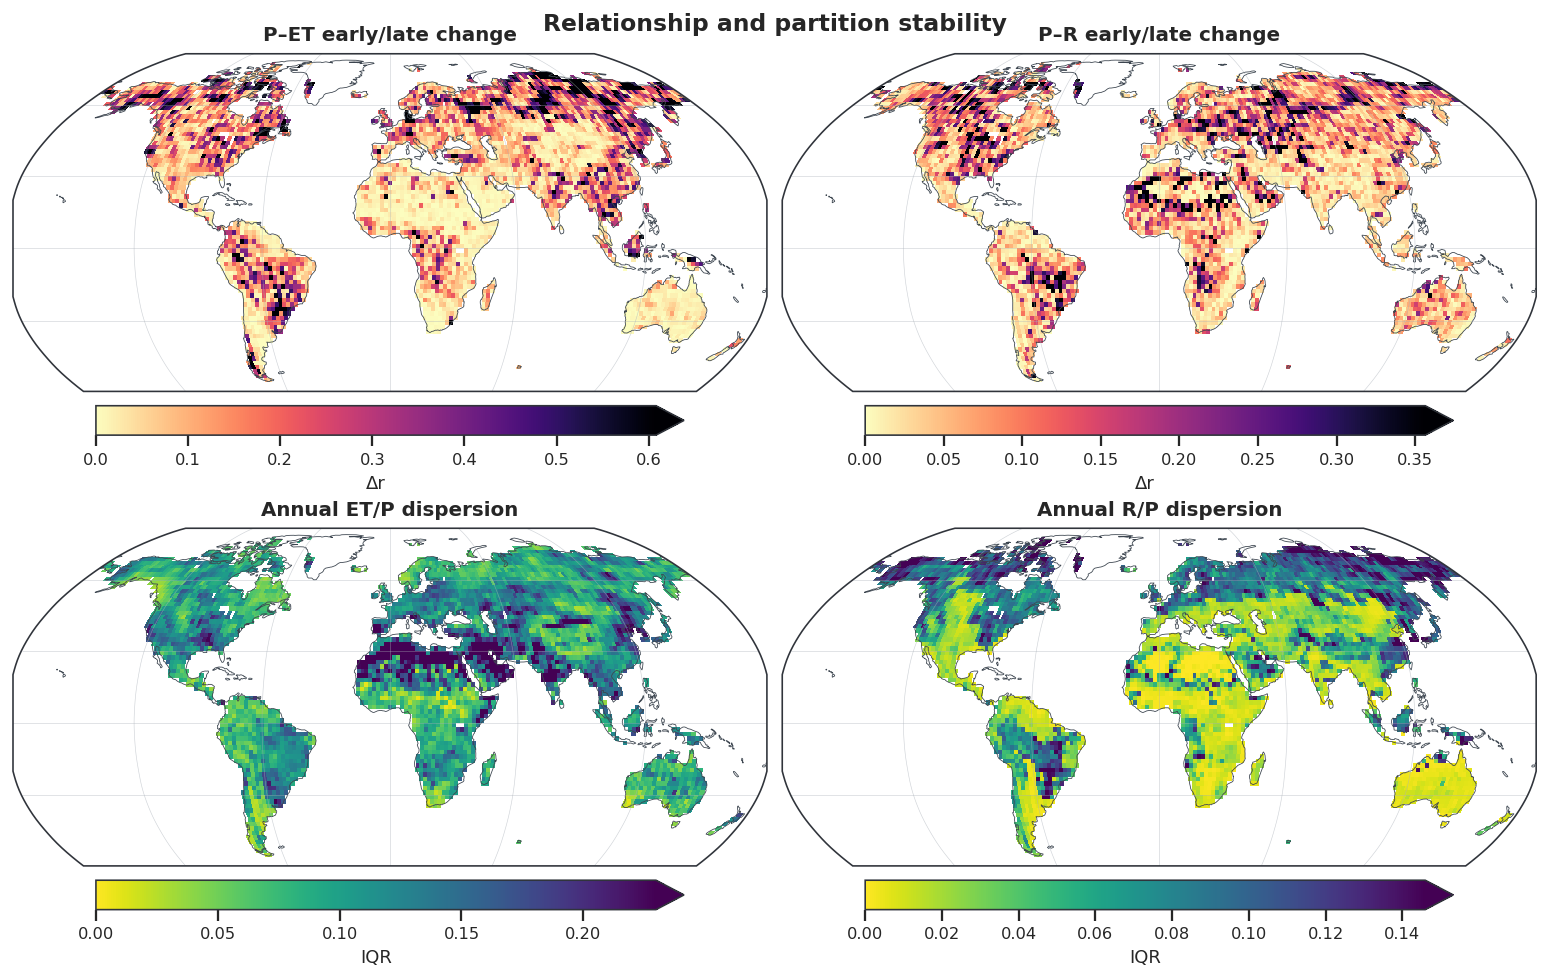

In [7]:
stability_specs = [
    ("r_P_ET_delta_abs", "P–ET early/late change", "magma_r", "Δr"),
    ("r_P_R_delta_abs", "P–R early/late change", "magma_r", "Δr"),
    ("ET_over_P_iqr", "Annual ET/P dispersion", "viridis_r", "IQR"),
    ("R_over_P_iqr", "Annual R/P dispersion", "viridis_r", "IQR"),
]
fig, axes = plt.subplots(
    2, 2, figsize=(11.8, 7.3), subplot_kw={"projection": projection},
    constrained_layout=True,
)
for ax, (column, title, cmap, label) in zip(axes.flat, stability_specs):
    upper = float(metrics[column].quantile(0.95))
    mesh = ax.pcolormesh(
        spatial.lon, spatial.lat, metric_grid(column),
        transform=ccrs.PlateCarree(), cmap=cmap, vmin=0, vmax=upper,
        shading="auto", rasterized=True,
    )
    style_map(ax)
    ax.set_title(title, pad=7)
    colorbar = fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.035, shrink=0.78, extend="max")
    colorbar.set_label(label)
fig.suptitle("Relationship and partition stability", y=1.01, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "grid_relationship_stability.png", bbox_inches="tight")
plt.show()


## Step 7 — Compare area-weighted distributions

**English.** Plot the land-area-weighted distributions of the three correlation coefficients and the two early/late changes. The vertical line is the area-weighted median. Weighting turns each histogram into a distribution over non-ice land area rather than a distribution over unequal grid cells.

**中文。** 绘制三个相关系数以及两个前后半期变化量的陆地面积加权分布，竖线表示面积加权中位数。经过加权后，直方图反映的是非冰川陆地面积上的分布，而不是不同大小网格的简单计数分布。


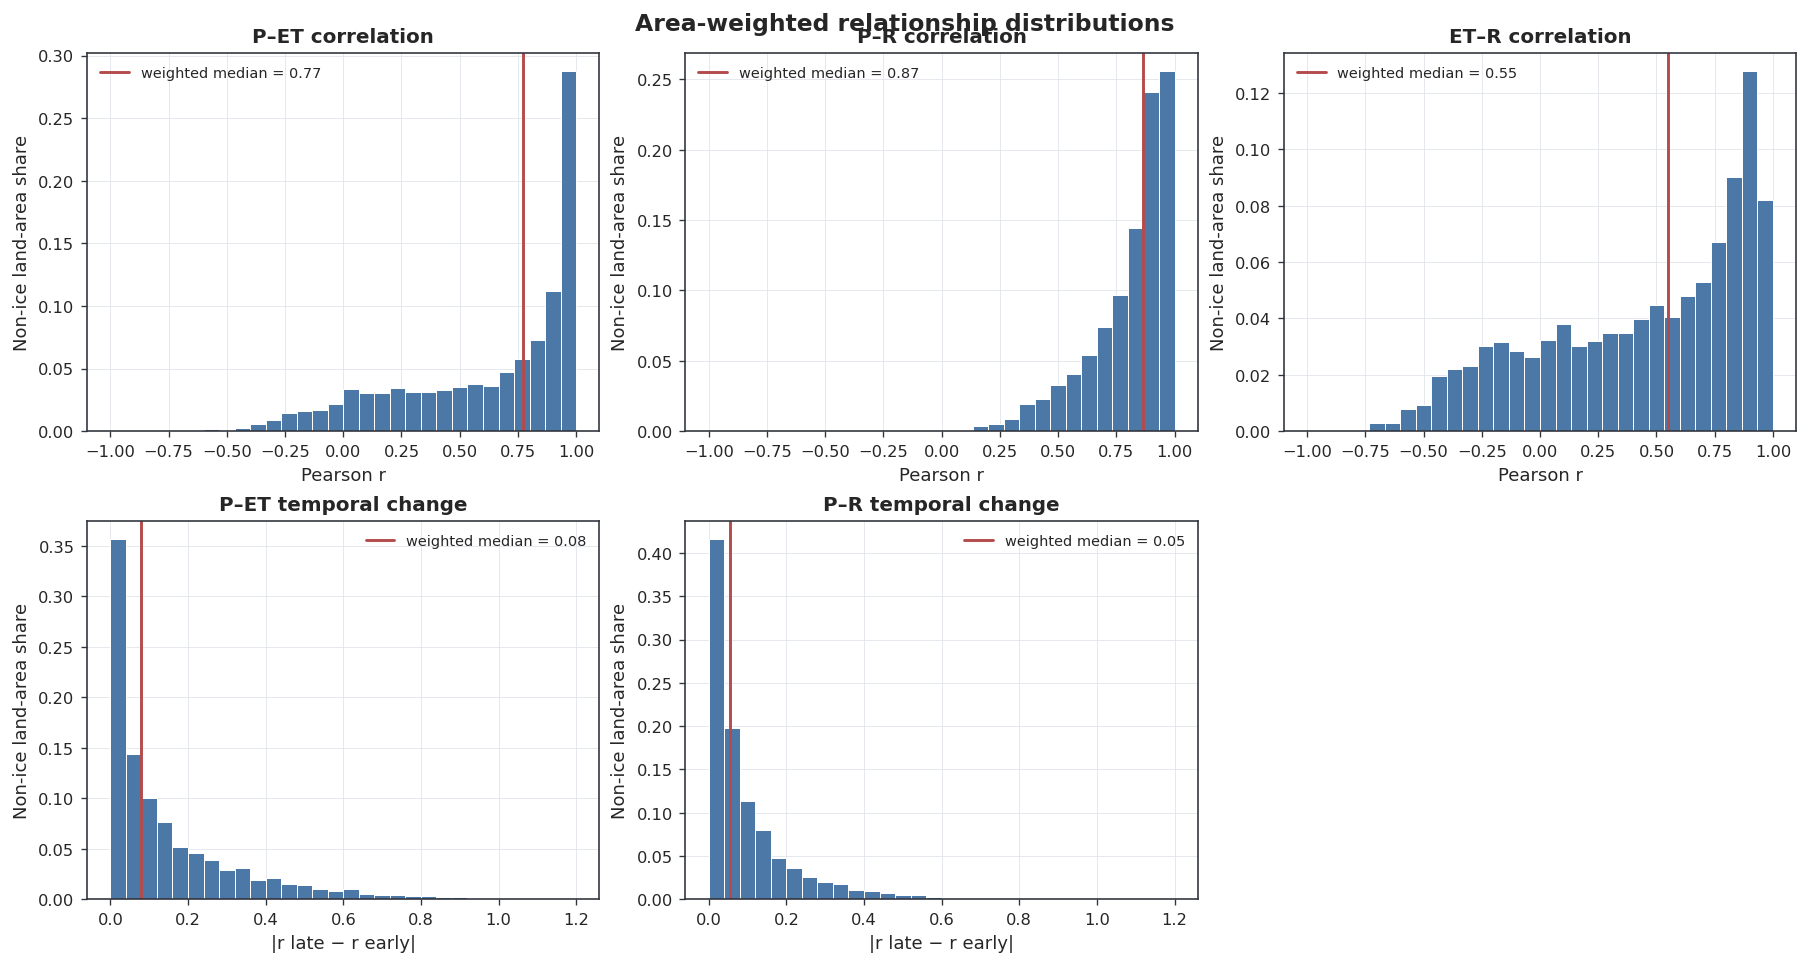

In [8]:
distribution_specs = [
    ("r_P_ET", "P–ET correlation", np.linspace(-1, 1, 31), "Pearson r"),
    ("r_P_R", "P–R correlation", np.linspace(-1, 1, 31), "Pearson r"),
    ("r_ET_R", "ET–R correlation", np.linspace(-1, 1, 31), "Pearson r"),
    ("r_P_ET_delta_abs", "P–ET temporal change", np.linspace(0, 1.2, 31), "|r late − r early|"),
    ("r_P_R_delta_abs", "P–R temporal change", np.linspace(0, 1.2, 31), "|r late − r early|"),
]
fig, axes = plt.subplots(2, 3, figsize=(13.8, 7.2), constrained_layout=True)
for ax, (column, title, bins, xlabel) in zip(axes.flat, distribution_specs):
    valid = metrics[column].notna()
    normalized_weights = weights[valid] / weights[valid].sum()
    ax.hist(
        metrics.loc[valid, column], bins=bins, weights=normalized_weights,
        color="#4C78A8", edgecolor="white", linewidth=0.55,
    )
    median = weighted_quantile(metrics[column], weights)
    ax.axvline(median, color="#B44A4A", linewidth=1.6, label=f"weighted median = {median:.2f}")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Non-ice land-area share")
    ax.legend(frameon=False, fontsize=8)
    style_axes(ax)
axes.flat[-1].axis("off")
fig.suptitle("Area-weighted relationship distributions", y=1.01, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "relationship_distributions.png", bbox_inches="tight")
plt.show()


## Step 8 — Inspect representative grid-cell time series

**English.** Select three diagnostic examples automatically: a stable strong P–ET grid, a stable strong P–R grid, and the grid with the largest P–ET early/late change. Stable examples must also have mean P ≥ 300, ET ≥ 100, and R ≥ 50 mm yr⁻¹, which prevents a nearly zero-flux desert cell from becoming a visually trivial example; this condition affects example selection only, not the analysis table. Standardized anomalies put P, ET, and R on a common scale so their co-movement is visible. These examples illustrate the metrics; they are not claimed to represent entire climate regions.

**中文。** 自动选择三个诊断性例子：一个 P–ET 强且稳定的网格、一个 P–R 强且稳定的网格，以及 P–ET 前后半期变化最大的网格。稳定示例另要求平均 P ≥ 300、ET ≥ 100、R ≥ 50 mm yr⁻¹，以避免几乎没有水分通量的沙漠网格成为视觉上无意义的例子；这一条件只影响示例选择，不会删除分析表中的网格。标准化距平将 P、ET、R 放在相同尺度上，便于观察同步变化。这些网格只用于解释指标含义，不代表完整气候区域。


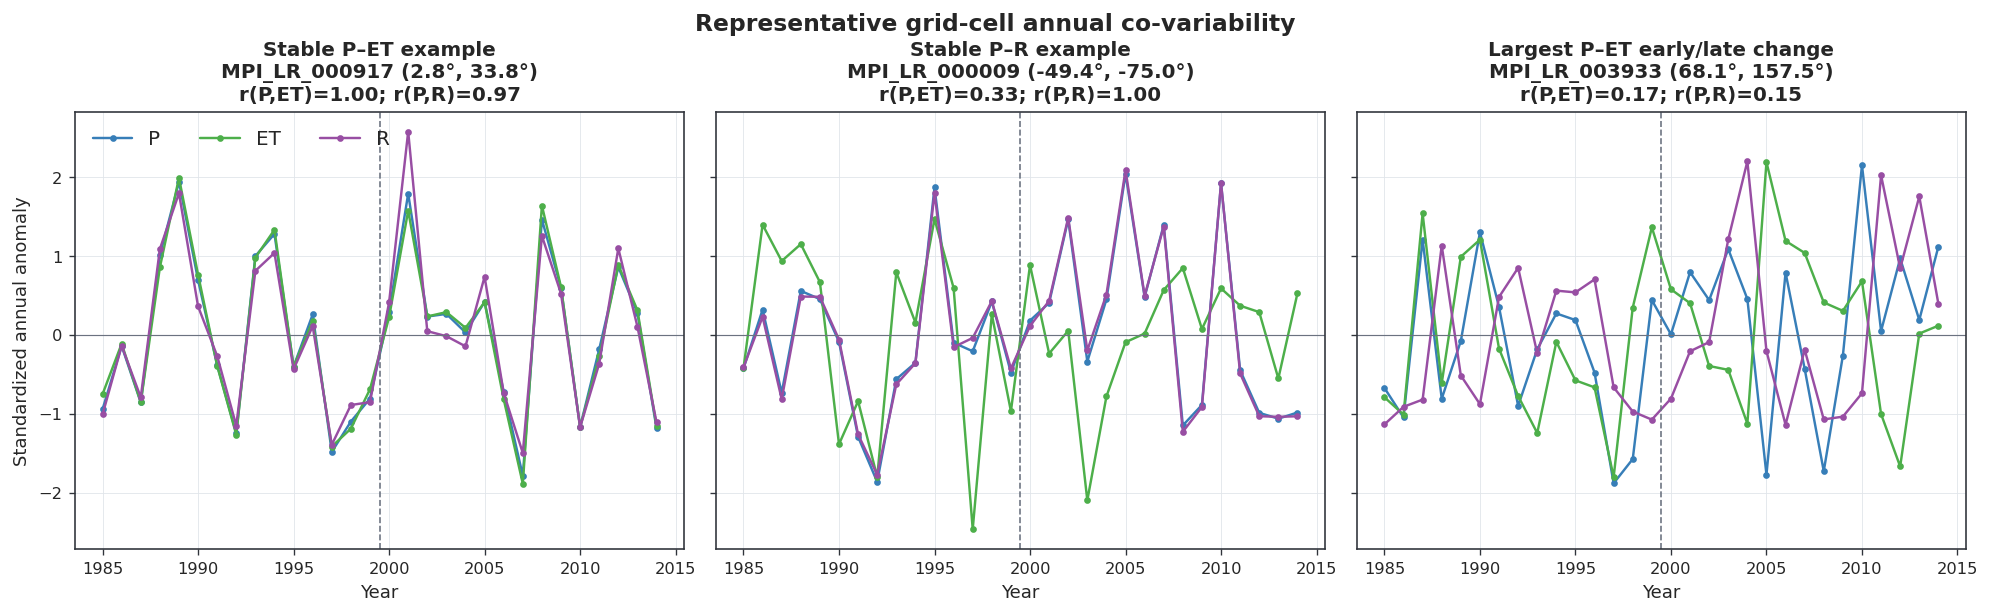

,lat,lon,r_P_ET,r_P_R,r_ET_R,r_P_ET_delta_abs,r_P_R_delta_abs,P_cv,ET_cv,R_cv
grid_id,,,,,,,,,,
MPI_LR_000917,2.798,33.75,0.996,0.974,0.960,0.001,0.028,0.263,0.258,0.325
MPI_LR_000009,-49.429,-75.00,0.330,0.998,0.270,0.522,0.002,0.090,0.041,0.104
MPI_LR_003933,68.081,157.50,0.167,0.147,-0.474,1.105,0.222,0.176,0.088,0.478


In [9]:
example_flux_mask = (metrics["P_mean"] >= 300) & (metrics["ET_mean"] >= 100) & (metrics["R_mean"] >= 50)
stable_pet = metrics.loc[metrics["P_ET_strong_stable"] & example_flux_mask].sort_values(
    ["r_P_ET", "r_P_ET_delta_abs"], ascending=[False, True]
).index[0]
stable_pr_candidates = metrics.loc[metrics["P_R_strong_stable"] & example_flux_mask].drop(index=stable_pet, errors="ignore")
stable_pr = stable_pr_candidates.sort_values(
    ["r_P_R", "r_P_R_delta_abs"], ascending=[False, True]
).index[0]
unstable_pet = metrics["r_P_ET_delta_abs"].idxmax()

examples = [
    (stable_pet, "Stable P–ET example"),
    (stable_pr, "Stable P–R example"),
    (unstable_pet, "Largest P–ET early/late change"),
]
colors = {"P": "#377EB8", "ET": "#4DAF4A", "R": "#984EA3"}
fig, axes = plt.subplots(1, 3, figsize=(15.2, 4.4), constrained_layout=True, sharey=True)
for ax, (grid_name, label) in zip(axes, examples):
    subset = annual.loc[annual["grid_id"] == grid_name, ["year", "P", "ET", "R"]].copy()
    for variable in ["P", "ET", "R"]:
        subset[f"{variable}_z"] = (subset[variable] - subset[variable].mean()) / subset[variable].std(ddof=1)
        ax.plot(
            subset["year"], subset[f"{variable}_z"], marker="o", markersize=2.7,
            linewidth=1.35, color=colors[variable], label=variable,
        )
    row = metrics.loc[grid_name]
    ax.axvline(1999.5, color="#6B7280", linewidth=0.9, linestyle="--")
    ax.axhline(0, color="#6B7280", linewidth=0.65)
    ax.set_title(
        f"{label}\n{grid_name} ({row['lat']:.1f}°, {row['lon']:.1f}°)\n"
        f"r(P,ET)={row['r_P_ET']:.2f}; r(P,R)={row['r_P_R']:.2f}"
    )
    ax.set_xlabel("Year")
    style_axes(ax)
axes[0].set_ylabel("Standardized annual anomaly")
axes[0].legend(frameon=False, ncol=3, loc="upper left")
fig.suptitle("Representative grid-cell annual co-variability", y=1.04, fontsize=13, fontweight="semibold")
fig.savefig(FIGURE_DIR / "representative_grid_timeseries.png", bbox_inches="tight")
plt.show()

display(metrics.loc[[name for name, _ in examples], [
    "lat", "lon", "r_P_ET", "r_P_R", "r_ET_R",
    "r_P_ET_delta_abs", "r_P_R_delta_abs", "P_cv", "ET_cv", "R_cv",
]].round(3))


## Step 9 — Save per-grid metrics and concise summaries

**English.** Save one analysis-ready Parquet row per grid cell, a gridded NetCDF version for mapping, a compact CSV summary, and publication-ready PNG figures. The Parquet file is the recommended input for later climate-region comparison or tree-based exploration because it preserves continuous diagnostics and stable grid identifiers.

**中文。** 保存四类结果：每个网格一行的分析型 Parquet、便于空间制图的 NetCDF、简洁的 CSV 汇总表，以及高分辨率 PNG 图。后续若要比较气候分区或进行 tree 探索，建议以 Parquet 为主要输入，因为它保留了连续诊断指标和稳定的网格编号。


In [10]:
METRICS_PARQUET = DERIVED_DIR / "MPI_ESM1_2_LR_grid_relationship_stability_1985_2014.parquet"
METRICS_NETCDF = DERIVED_DIR / "MPI_ESM1_2_LR_grid_relationship_stability_1985_2014.nc"
SUMMARY_CSV = DERIVED_DIR / "MPI_ESM1_2_LR_relationship_summary_1985_2014.csv"

metric_columns_for_netcdf = [
    "r_P_ET", "r_P_R", "r_ET_R", "rho_P_ET", "rho_P_R", "rho_ET_R",
    "P_to_ET_slope", "P_to_R_slope",
    "r_P_ET_early", "r_P_ET_late", "r_P_ET_delta_abs",
    "r_P_R_early", "r_P_R_late", "r_P_R_delta_abs",
    "P_cv", "ET_cv", "R_cv",
    "ET_fraction_longterm", "R_fraction_longterm", "partition_sum_longterm",
    "ET_over_P_iqr", "R_over_P_iqr",
    "WB_mean", "WB_sd", "WB_mae", "WB_rmse", "WB_relative_percent",
]
relationship_grid = xr.Dataset({column: metric_grid(column) for column in metric_columns_for_netcdf})
relationship_grid["grid_id"] = spatial["grid_id"].fillna(-1).astype("int32")
relationship_grid["analysis_cell"] = spatial["analysis_cell"].astype("int8")
relationship_grid["land_area"] = spatial["land_area"].astype("float32")
relationship_grid.attrs.update({
    "title": "MPI-ESM1-2-LR grid-level annual P-ET-R relationships and stability",
    "source_id": spatial.attrs.get("source_id"),
    "variant_label": spatial.attrs.get("variant_label"),
    "grid_label": spatial.attrs.get("grid_label"),
    "experiment_id": spatial.attrs.get("experiment_id"),
    "analysis_period": f"{START_YEAR}-{END_YEAR}",
    "early_period": f"{START_YEAR}-{EARLY_END}",
    "late_period": f"{LATE_START}-{END_YEAR}",
    "note": "Descriptive grid-level diagnostics; correlations do not imply causality.",
})

if WRITE_OUTPUTS:
    DERIVED_DIR.mkdir(parents=True, exist_ok=True)
    metrics.reset_index().to_parquet(METRICS_PARQUET, index=False)
    relationship_summary.to_csv(SUMMARY_CSV)
    encoding = {name: {"zlib": True, "complevel": 4} for name in relationship_grid.data_vars}
    relationship_grid.to_netcdf(METRICS_NETCDF, encoding=encoding)

manifest = pd.DataFrame([
    {"product": "Per-grid metric table", "path": METRICS_PARQUET, "rows_or_cells": len(metrics)},
    {"product": "Gridded relationship metrics", "path": METRICS_NETCDF, "rows_or_cells": int(spatial.analysis_cell.sum())},
    {"product": "Relationship summary", "path": SUMMARY_CSV, "rows_or_cells": len(relationship_summary)},
    {"product": "Figure directory", "path": FIGURE_DIR, "rows_or_cells": len(list(FIGURE_DIR.glob("*.png")))},
])
if WRITE_OUTPUTS:
    manifest["exists"] = manifest["path"].map(Path.exists)
    manifest["size_MB"] = manifest["path"].map(
        lambda path: np.nan if path.is_dir() else path.stat().st_size / 1e6
    )
display(manifest)


,product,path,rows_or_cells,exists,size_MB
0,Per-grid metric table,/Users/mimi/Documents/Code/Github/GSA-work/exp...,4172,True,0.942482
1,Gridded relationship metrics,/Users/mimi/Documents/Code/Github/GSA-work/exp...,4172,True,0.588416
2,Relationship summary,/Users/mimi/Documents/Code/Github/GSA-work/exp...,3,True,0.000402
3,Figure directory,/Users/mimi/Documents/Code/Github/GSA-work/exp...,4,True,NaN


## Step 10 — Interpretation guardrails and completion checklist

**English.** The resulting correlations describe year-to-year co-variability inside one ESM simulation. They do not establish causal direction, and 30 annual samples are too few for fine regional inference without uncertainty analysis. Early/late differences are diagnostics, not formal change-point tests. High ratio dispersion in very dry grids should be interpreted together with P mean, valid ratio-year count, and absolute fluxes.

**中文。** 这些相关系数描述的是同一个 ESM 模拟内部的年际共同变化，不能直接证明因果方向。每个网格只有 30 个年度样本，因此若要进行精细区域推断，还需要进一步的不确定性分析。前后半期差异只是诊断指标，并不是正式的突变检验。对于非常干旱的网格，较大的比例离散程度必须结合平均 P、比例有效年份数以及 P、ET、R 的绝对量共同解释。

完成本 notebook 后应获得：

- 每个非冰川陆地网格的 P–ET、P–R、ET–R 关系指标；
- 前后 15 年关系方向和强度的一致性诊断；
- P、ET、R 年际变异与 ET/P、R/P 稳定性指标；
- WB 残差稳定性指标；
- 可供下一步气候分区比较或 tree 探索使用的标准化结果文件。


In [11]:
reopened_metrics = pd.read_parquet(METRICS_PARQUET)
reopened_grid = xr.open_dataset(METRICS_NETCDF)

completion = pd.Series({
    "per_grid_rows": len(reopened_metrics),
    "unique_grid_ids": reopened_metrics["grid_id"].nunique(),
    "gridded_analysis_cells": int(reopened_grid["analysis_cell"].sum()),
    "missing_core_correlations": int(reopened_metrics[["r_P_ET", "r_P_R", "r_ET_R"]].isna().sum().sum()),
    "saved_png_figures": len(list(FIGURE_DIR.glob("*.png"))),
})
display(completion.to_frame("value"))

assert completion["per_grid_rows"] == completion["unique_grid_ids"] == int(spatial.analysis_cell.sum())
assert completion["missing_core_correlations"] == 0
assert completion["saved_png_figures"] == 4

reopened_grid.close()
spatial.close()
print("Step 3 completed successfully.")


,value
per_grid_rows,4172
unique_grid_ids,4172
gridded_analysis_cells,4172
missing_core_correlations,0
saved_png_figures,4


Step 3 completed successfully.
